# Seminar 02 — Imitation Learning: Behavior Cloning & Distribution Shift

**student** · SO-101 / MuJoCo · Python / PyTorch · Google Colab

In this seminar you will train a continuous-control policy from demonstrations, discover why a
small offline loss can coexist with failed robot rollouts, and repair part of that gap with
Dataset Aggregation (DAgger). The policy observes privileged simulator state so that perception
does not obscure the imitation-learning problem. Vision and sequence models arrive in the next
seminar.

**Required:** Task 1 (Behavior Cloning) and Task 2 (DAgger).  
**Bonus karma:** Task 3 (multicube goal-conditioned imitation learning).

Run the notebook from top to bottom. Replace every `TO DO` and `NotImplementedError`, keep your
plots and written interpretations, and submit the completed notebook. A full run is designed for
about 10–15 minutes on a Colab T4; the teaching session is 90 minutes.

## A. Google Colab setup

In Colab, select **Runtime → Change runtime type → T4 GPU** before running this cell. PyTorch is
already matched to the Colab CUDA runtime, so the notebook keeps that installation and adds only
the simulator, plotting, widget, and MP4 dependencies. `MUJOCO_GL=egl` enables offscreen MuJoCo
rendering without a desktop window.

In [1]:
import os, sys, subprocess

os.environ.setdefault('MUJOCO_GL', 'egl')
IN_COLAB = 'google.colab' in sys.modules
COLAB_PACKAGES = [
    'mujoco>=3.2,<4', 'matplotlib>=3.8', 'pandas>=2', 'ipywidgets>=8',
    'imageio>=2.34', 'imageio-ffmpeg>=0.5', 'pillow>=10',
]
if IN_COLAB:
    print('Installing Colab dependencies...')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                    *COLAB_PACKAGES], check=True)
    from google.colab import output
    output.enable_custom_widget_manager()
    print('Colab dependencies installed; EGL rendering enabled.')
else:
    print('Local runtime detected; using packages from the active environment.')

Installing Colab dependencies...
Colab dependencies installed; EGL rendering enabled.


## Learning objectives and scope

By the end you should be able to:

1. write Behavior Cloning as supervised learning on expert state-action pairs;
2. explain the tensor shapes and loss of a continuous action-chunking MLP;
3. distinguish held-out demonstration loss from closed-loop task success;
4. identify covariate shift and the mechanism of compounding errors;
5. implement one intervention-based DAgger cycle;
6. explain why BC remains a mandatory baseline before a larger VLA policy.

The MuJoCo robot, scene geometry, contacts, and obstacle collisions come from the SO-101 setup.
For reliable completion in a short browser-based laboratory, grasp attachment is assisted after
the gripper reaches a documented capture region. Navigation remains simulated. This isolates the
learning question from fragile contact tuning; it must not be interpreted as evidence of robust
physical grasping.

### Locate the seminar files and verify the runtime

The original desktop teleoperation loop uses an OpenCV window. Colab instead renders offscreen
with EGL and displays frames in the notebook. If only the `.ipynb` file was uploaded, this cell
clones the course repository to obtain `seminar_il.py` and the SO-101 MuJoCo assets.

In [2]:
import platform, time
from pathlib import Path

candidates = [Path.cwd(), *Path.cwd().parents]
SEMINAR_DIR = next((p / rel for p in candidates
                    for rel in ['02-imitation-learning', '.']
                    if (p / rel / 'assets/so101_gym/so100_transfer_cube_obstacle_ee.xml').is_file()), None)
if SEMINAR_DIR is None and IN_COLAB:
    checkout = Path('/content/multimodal-vla-course')
    if checkout.exists() and (checkout / '.git').is_dir():
        print('Updating the existing course checkout...')
        subprocess.run(['git', '-C', str(checkout), 'pull', '--ff-only'], check=True)
    elif checkout.exists() and not (checkout / '.git').is_dir():
        raise FileExistsError(
            f'{checkout} exists but is not a Git checkout. Remove or rename it, then rerun this cell.')
    elif not checkout.exists():
        subprocess.run(['git', 'clone', '-q',
                        'https://github.com/wingrune/multimodal-vla-course.git', str(checkout)], check=True)
    SEMINAR_DIR = checkout / '02-imitation-learning'
if SEMINAR_DIR is None:
    raise FileNotFoundError('Could not locate 02-imitation-learning. See the repository README.')

module_candidates = [SEMINAR_DIR / 'notebooks', SEMINAR_DIR]
MODULE_DIR = next((p for p in module_candidates if (p / 'seminar_il.py').is_file()), None)
if MODULE_DIR is None:
    raise FileNotFoundError(
        f'seminar_il.py was not found under {SEMINAR_DIR}. Rerun the setup cells in a fresh runtime.')
sys.path.insert(0, str(MODULE_DIR))

import base64, tempfile
import imageio.v2 as imageio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from IPython.display import HTML, display, clear_output
from seminar_il import (SO101Env, ScriptedExpert, chunk_episode,
                        generate_expert_dataset, run_chunked_policy, evaluate_policy)

SEED, CHUNK_SIZE = 42, 16
np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cpu': torch.set_num_threads(2)
print(f'Python {platform.python_version()} | torch {torch.__version__} | device={device}')
print('Seminar directory:', SEMINAR_DIR)
print('Runtime module:', MODULE_DIR / 'seminar_il.py')
if IN_COLAB and device.type != 'cuda':
    print('WARNING: no GPU detected. Select Runtime > Change runtime type > T4 GPU.')

Python 3.13.15 | torch 2.11.0+cu128 | device=cuda
Seminar directory: /content/multimodal-vla-course/02-imitation-learning
Runtime module: /content/multimodal-vla-course/02-imitation-learning/notebooks/seminar_il.py


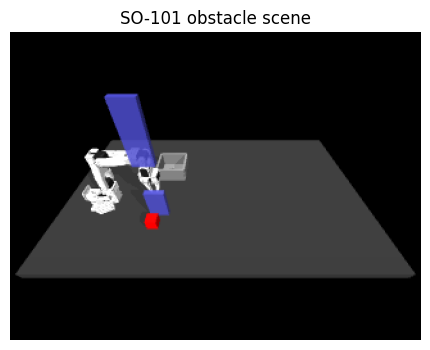

,feature,slice,meaning
0,end-effector xyz,0:3,"m, world frame"
1,jaw angle,3:4,rad
2,cube xyz,4:7,"m, world frame"
3,obstacle xyz,7:10,"m, world frame"
4,bin xyz,10:13,"m, world frame"


state: (13,) [-0.231  0.5    0.115  0.    -0.229  0.399  0.02  -0.214  0.45   0.06
 -0.2    0.7    0.021] | action: [dx, dy, dz, jaw_target]


In [3]:
env = SO101Env(seed=0)
state = env.state()
fig, ax = plt.subplots(figsize=(6, 4))
ax.imshow(env.render('angle')); ax.axis('off'); ax.set_title('SO-101 obstacle scene')
plt.show()
feature_table = pd.DataFrame([
    ('end-effector xyz', '0:3', 'm, world frame'),
    ('jaw angle', '3:4', 'rad'), ('cube xyz', '4:7', 'm, world frame'),
    ('obstacle xyz', '7:10', 'm, world frame'), ('bin xyz', '10:13', 'm, world frame')],
    columns=['feature', 'slice', 'meaning'])
display(feature_table)
print('state:', state.shape, np.round(state, 3), '| action: [dx, dy, dz, jaw_target]')
env.close()

## B. Dataset fields and action convention

The environment exposes named physical quantities, while the compact training dataset stores
already concatenated tensors. Keeping both schemas explicit prevents silent changes in feature
order, units, or target meaning.

### Single-cube observation fields

| Field | Dim | Description |
|---|---:|---|
| `ee_xyz` | 3 | End-effector Cartesian position $(x,y,z)$ in the MuJoCo world frame, metres. |
| `gripper` | 1 | Measured jaw joint angle in radians. It is part of the observation, not the commanded action. |
| `cube_xyz` | 3 | Red cube centre position in the world frame, metres. |
| `obstacle_xyz` | 3 | Obstacle body position in the world frame, metres. Adversarial evaluation samples its x coordinate from the HW3 three-zone mixture. |
| `goal_xyz` | 3 | Bin-centre position in the world frame, metres. |

These fields are concatenated in exactly this order into `state[t]` with shape `(13,)`:

$$s_t=[p_t^{ee}, q_t^{jaw}, p_t^{cube}, p_t^{obstacle}, p^{bin}].$$

### Continuous action fields

| Field | Dim | Description |
|---|---:|---|
| `delta_ee_xyz` | 3 | Change applied to the Cartesian mocap target during one 20 Hz control step, metres per step. Values are clipped to ±0.012 m. |
| `gripper_target` | 1 | Absolute jaw actuator target in radians: approximately `0.70` open and `-0.17` closed. |

The two parts deliberately use different conventions: Cartesian motion is a **delta**, while the
jaw command is an **absolute target**. Feature-wise action normalization prevents the larger jaw
range from dominating the Cartesian coordinates.

### Arrays returned by `generate_expert_dataset`

| Dataset key | Shape | Meaning |
|---|---|---|
| `state` | `(N, 13)` | Observation at the start of each supervised example. |
| `action_chunk` | `(N, H, 4)` | Expert actions $[a_t,\ldots,a_{t+H-1}]$; here `H = CHUNK_SIZE = 16`. |
| `episode` | `(N,)` | Integer demonstration identity used for episode-level train/validation splitting. |

Only starting rows with a complete chunk are retained. A chunk never crosses a reset or joins two
episodes. Adjacent rows overlap in time, so a random row split would leak nearly identical windows
between training and validation; we split using `episode` instead.

### Multicube observation fields (Task 3)

| Field | Dim | Description |
|---|---:|---|
| `ee_xyz` | 3 | End-effector Cartesian position, metres. |
| `gripper` | 1 | Measured jaw angle, radians. |
| `cube_xyz_red` | 3 | Red cube centre position, metres. |
| `cube_xyz_green` | 3 | Green cube centre position, metres. |
| `cube_xyz_blue` | 3 | Blue cube centre position, metres. |
| `goal_xyz` | 3 | Bin-centre position, metres. |
| `goal_one_hot` | 3 | Target identity: red `[1,0,0]`, green `[0,1,0]`, or blue `[0,0,1]`. |

Their concatenation has shape `(19,)`. Cube order is fixed by color even though cube positions are
randomized. The action schema remains `(4,)`. Orientations, images, and language embeddings are
intentionally absent: this seminar isolates imitation learning with privileged simulator state.

## C. Task visualization and expert trajectories

Before fitting a policy, inspect the three obstacle conditions used in ETH HW3. Let $x_0$ be the
default obstacle coordinate. Training samples only the centre zone,
$x=x_0+\mathcal N(0,0.01^2)$. Adversarial evaluation samples a mixture:

| Adversarial component | Probability | Obstacle x coordinate |
|---|---:|---|
| Centre (train-like) | 20% | $x_0+\mathcal N(0,0.01^2)$ |
| Positive side | 40% | $x_0+0.08+\mathcal N(0,0.005^2)$ |
| Negative side | 40% | $x_0-0.08+\mathcal N(0,0.005^2)$ |

Thus, `adversarial` is not synonymous with "always shifted": one fifth of its episodes are drawn
from the original centre distribution. The other four fifths expose the policy to obstacle
positions absent from the BC demonstrations. The cube still receives the HW3 Gaussian xy noise
with standard deviation 0.006 m in every condition.

The figure and videos below show one successful expert rollout from each mixture component. The
camera columns show the initial and terminal scenes. In the top-down plots, the solid curve is the
end-effector path and the dashed curve is the cube path; the blue rectangle is the obstacle and the
grey square is the bin. The videos replay the same rollouts at approximately real-time speed. Pause
them to identify reaching, grasping, obstacle avoidance, and release. Our 4D action keeps the wrist
orientation fixed. In the negative side zone, the expert therefore uses the gap below the upper
barrier at a lower transit height; a high route would make the lower arm collide with that barrier.

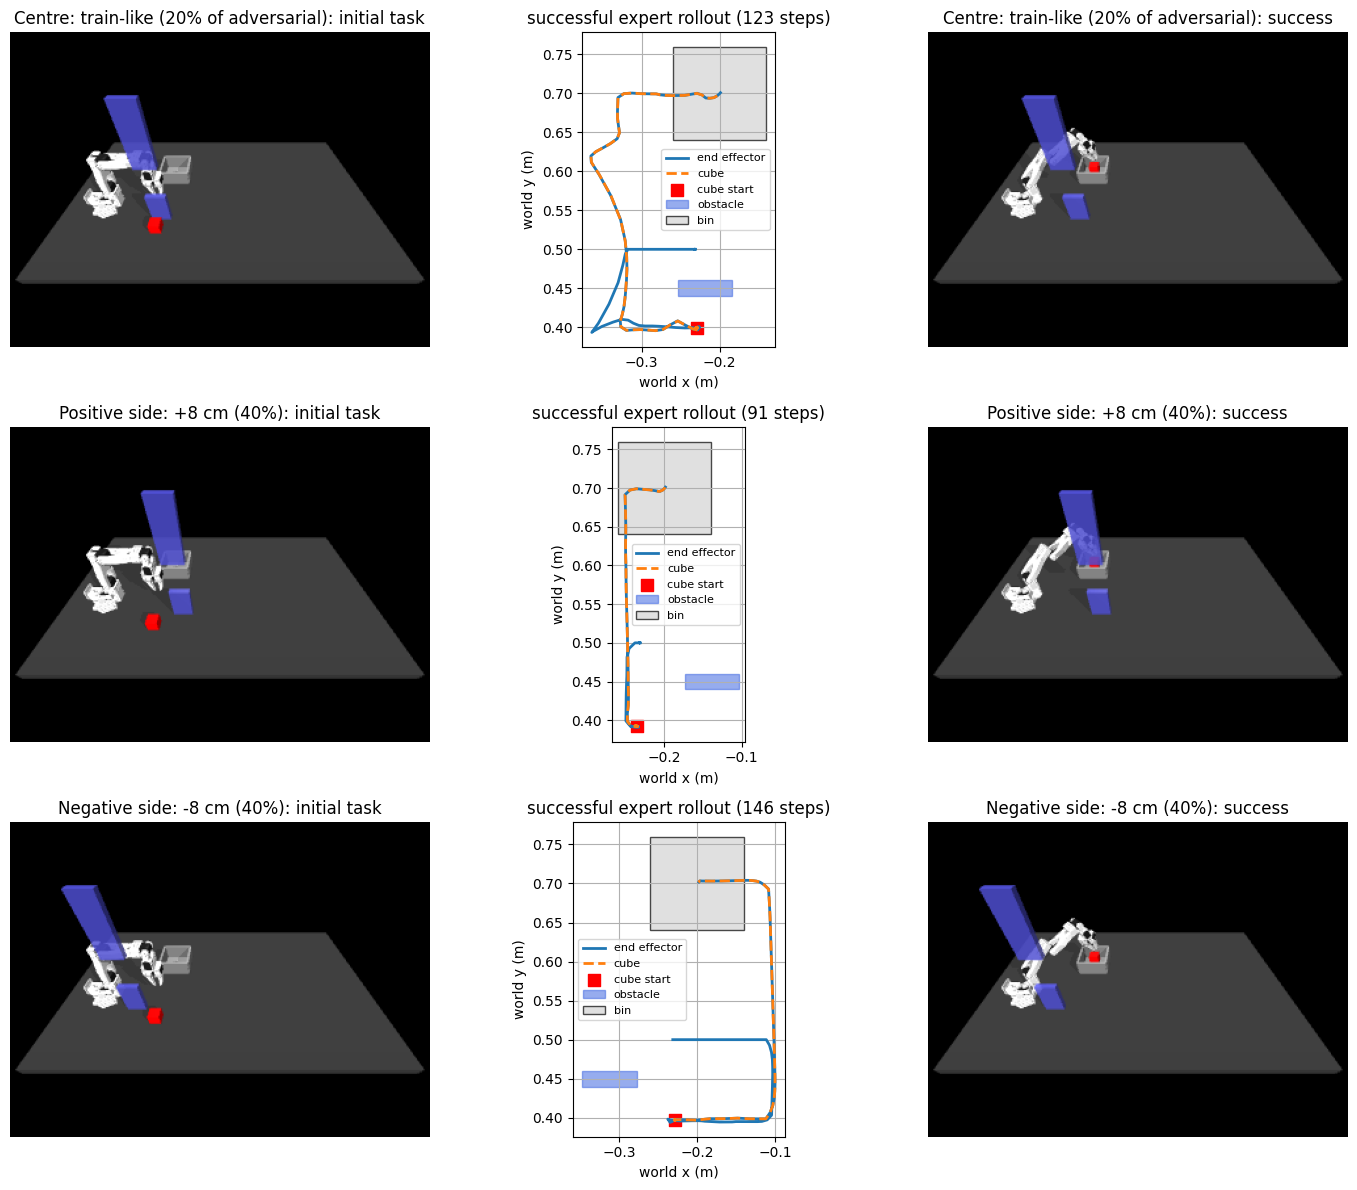

,condition,steps,obstacle_x,final_cube_to_bin_xy,success
0,Centre: train-like (20% of adversarial),123,-0.218951,0.000975,True
1,Positive side: +8 cm (40%),91,-0.137898,0.001392,True
2,Negative side: -8 cm (40%),146,-0.312207,0.002114,True


In [4]:
from matplotlib.patches import Rectangle

def record_expert_trajectory(mode, seed, expected_zone, label):
    env = SO101Env(seed=seed, obstacle_mode=mode, render_size=(320, 240))
    assert env.obstacle_zone == expected_zone, (seed, env.obstacle_zone, expected_zone)
    initial_frame = env.render('angle')
    frames = [initial_frame]
    initial_cube = env.cube_pos().copy()
    obstacle = env.obstacle_pos.copy()
    bin_pos = env.bin_pos.copy()
    expert = ScriptedExpert(env)
    ee_path, cube_path = [env.ee_pos], [env.cube_pos()]
    for step in range(420):
        env.step(expert.action())
        ee_path.append(env.ee_pos); cube_path.append(env.cube_pos())
        if (step + 1) % 2 == 0:
            frames.append(env.render('angle'))
        if env.success() or env.failed():
            break
    success = env.success()
    final_frame = env.render('angle')
    if not np.array_equal(frames[-1], final_frame):
        frames.append(final_frame)
    env.close()
    assert success, f'Expert trajectory for {label} did not succeed'
    return {'mode': mode, 'zone': env.obstacle_zone, 'label': label,
            'initial_frame': initial_frame, 'final_frame': final_frame,
            'frames': frames,
            'ee': np.stack(ee_path), 'cube': np.stack(cube_path),
            'initial_cube': initial_cube, 'obstacle': obstacle, 'bin': bin_pos}

trajectories = [
    record_expert_trajectory('adversarial', 0, 'center',
                             'Centre: train-like (20% of adversarial)'),
    record_expert_trajectory('adversarial', 5, '+8 cm side',
                             'Positive side: +8 cm (40%)'),
    record_expert_trajectory('adversarial', 2, '-8 cm side',
                             'Negative side: -8 cm (40%)'),
]
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
for row, trajectory in enumerate(trajectories):
    axes[row, 0].imshow(trajectory['initial_frame']); axes[row, 0].axis('off')
    axes[row, 0].set_title(f"{trajectory['label']}: initial task")

    ax = axes[row, 1]
    ax.plot(trajectory['ee'][:, 0], trajectory['ee'][:, 1], lw=2, label='end effector')
    ax.plot(trajectory['cube'][:, 0], trajectory['cube'][:, 1], '--', lw=2, label='cube')
    ax.scatter(*trajectory['initial_cube'][:2], marker='s', s=65, color='red', label='cube start')
    obstacle = trajectory['obstacle']
    bin_pos = trajectory['bin']
    ax.add_patch(Rectangle((obstacle[0] - .035, obstacle[1] - .01), .07, .02,
                           color='royalblue', alpha=.55, label='obstacle'))
    ax.add_patch(Rectangle((bin_pos[0] - .06, bin_pos[1] - .06), .12, .12,
                           facecolor='lightgrey', edgecolor='black', alpha=.7, label='bin'))
    ax.set(xlabel='world x (m)', ylabel='world y (m)',
           title=f"successful expert rollout ({len(trajectory['ee'])-1} steps)")
    ax.set_aspect('equal'); ax.grid(True); ax.legend(fontsize=8, loc='best')

    axes[row, 2].imshow(trajectory['final_frame']); axes[row, 2].axis('off')
    axes[row, 2].set_title(f"{trajectory['label']}: success")
plt.tight_layout(); plt.show()
display(pd.DataFrame([{'condition': t['label'], 'steps': len(t['ee']) - 1,
                       'obstacle_x': t['obstacle'][0],
                       'final_cube_to_bin_xy': np.linalg.norm(t['cube'][-1, :2] - t['bin'][:2]),
                       'success': True} for t in trajectories]))

def embedded_mp4(frames, fps=10):
    fd, filename = tempfile.mkstemp(suffix='.mp4')
    os.close(fd)
    path = Path(filename)
    try:
        imageio.mimsave(path, frames, fps=fps, codec='libx264', quality=7,
                        macro_block_size=None)
        payload = base64.b64encode(path.read_bytes()).decode('ascii')
    finally:
        path.unlink(missing_ok=True)
    return (f'<video controls loop muted playsinline width="480" '
            f'src="data:video/mp4;base64,{payload}"></video>')

video_cards = ''.join(
    f'<div style="flex:1;min-width:320px"><h4>{t["label"]}</h4>'
    f'{embedded_mp4(t["frames"])}</div>'
    for t in trajectories
)
display(HTML(f'<div style="display:flex;gap:16px;flex-wrap:wrap">{video_cards}</div>'))

### Optional browser teleoperation warm-up

Each click applies three control steps and refreshes the camera. Toggle **Record** to collect your
own `(state, action)` pairs. Browser-to-kernel latency makes this deliberately slower than a local
50 Hz teleoperation window; the supplied dataset keeps the assessed tasks reproducible.

In [ ]:
import ipywidgets as widgets

teleop_env = SO101Env(seed=7)
teleop_states, teleop_actions = [], []
record = widgets.ToggleButton(description='Record', icon='circle')
view = widgets.Output()

commands = {'x−': [-.01,0,0,.70], 'x+': [.01,0,0,.70],
            'y−': [0,-.01,0,.70], 'y+': [0,.01,0,.70],
            'z−': [0,0,-.01,.70], 'z+': [0,0,.01,.70],
            'close': [0,0,0,-.17], 'open': [0,0,0,.70]}
def refresh():
    with view:
        clear_output(wait=True)
        plt.figure(figsize=(5,3)); plt.imshow(teleop_env.render()); plt.axis('off'); plt.show()
        print('recorded steps:', len(teleop_states))
def apply_command(action):
    action = np.asarray(action, dtype=np.float32)
    for _ in range(3):
        if record.value:
            teleop_states.append(teleop_env.state()); teleop_actions.append(action.copy())
        teleop_env.step(action)
    refresh()
buttons = []
for label, action in commands.items():
    button = widgets.Button(description=label, layout=widgets.Layout(width='70px'))
    button.on_click(lambda _, a=action: apply_command(a)); buttons.append(button)
reset = widgets.Button(description='Reset')
reset.on_click(lambda _: (teleop_env.reset(), refresh()))
teleop_panel = widgets.VBox([widgets.HBox(buttons[:4]), widgets.HBox(buttons[4:]),
                             widgets.HBox([record, reset]), view])
if IN_COLAB:
    display(teleop_panel); refresh()
else:
    print('Teleoperation panel created. Display teleop_panel in an interactive notebook to use it.')

## Task 1 — Behavior Cloning (required)

### Theory: supervised learning with sequential consequences

An expert produces demonstrations
$\mathcal D_E=\{(s_t,a_t^E)\}$. Behavior Cloning fits a policy on that fixed dataset:

$$\theta^*=\arg\min_\theta\;\mathbb E_{(s,a^E)\sim\mathcal D_E}
\left[\ell\left(\pi_\theta(s),a^E\right)\right].$$

This looks like ordinary regression. Deployment is different: the policy's action changes the
next state, so inputs come from the policy-induced distribution $d_{\pi_\theta}$ rather than the
expert distribution $d_E$.

The continuous action is `[dx, dy, dz, jaw_target]`. Its coordinates have different scales, so
we fit state and action normalization on training episodes only. The MLP predicts 16 future
actions from one state. It is an action-chunking baseline, not a sequence model:

$$s_t\in\mathbb R^{13}\rightarrow\text{MLP}\rightarrow
\hat A_t\in\mathbb R^{16\times4}.$$

The next seminar will replace this flat decoder with a sequence model and study execution and
temporal ensembling in depth.

In [5]:
start = time.time()
bc_data = generate_expert_dataset(
    lambda seed: SO101Env(seed=seed, obstacle_mode='train', render_size=(96, 72)),
    episodes=20, chunk_size=CHUNK_SIZE)
print({k: v.shape for k, v in bc_data.items()}, f'generated in {time.time()-start:.1f}s')
train_mask = bc_data['episode'] < 16
val_mask = ~train_mask
print('train/validation examples:', train_mask.sum(), val_mask.sum())

{'state': (2358, 13), 'action_chunk': (2358, 16, 4), 'episode': (2358,)} generated in 7.2s
train/validation examples: 1917 441


In [6]:
class Normalizer:
    def fit(self, states, chunks):
        self.state_mean = states.mean(0)
        self.state_std = np.maximum(states.std(0), 1e-5)
        flat_actions = chunks.reshape(-1, chunks.shape[-1])
        self.action_mean = flat_actions.mean(0)
        self.action_std = np.maximum(flat_actions.std(0), 1e-5)
        return self
    def state(self, x): return (x - self.state_mean) / self.state_std
    def action(self, x): return (x - self.action_mean) / self.action_std
    def undo_action(self, x): return x * self.action_std + self.action_mean

### 1.1 Implement the action-chunking MLP

Build a 3-layer MLP. `forward` must return `(batch, chunk_size, action_dim)`, not a flat vector.

<details><summary>Hint 1</summary>

The final layer has `chunk_size * action_dim` outputs.

</details>
<details><summary>Hint 2</summary>

Use `reshape(-1, self.chunk_size, self.action_dim)` after the MLP.

</details>

In [12]:
class ChunkPolicy(nn.Module):
    def __init__(self, state_dim, action_dim=4, chunk_size=16, hidden_dim=256):
        super().__init__()
        self.model = nn.Sequential(nn.Linear(state_dim, hidden_dim), nn.ReLU(),
        nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
        nn.Linear(hidden_dim, self.chunk_size * self.action_dim))
        self.chunk_size, self.action_dim = chunk_size, action_dim
    def forward(self, state):
        # TO DO: map (B, state_dim) to (B, chunk_size, action_dim)
        out = self.model(state)
        return out.reshape(-1, self.chunk_size, self.action_dim)

### 1.2 Implement continuous-action BC loss

Return the mean squared error over batch, time, and normalized action coordinates.

<details><summary>Hint 1</summary>

Subtract tensors with identical `(B,H,A)` shapes.

</details>
<details><summary>Hint 2</summary>

Square, then average all axes.

</details>

In [13]:
def bc_loss(predicted_chunk, expert_chunk):
    # TO DO: normalized continuous-action regression loss.
    return ((predicted_chunk - expert_chunk) ** 2).mean()



In [14]:
def train_policy(states, chunks, train_rows, *, model_cls=ChunkPolicy,
                 epochs=180, batch_size=128, lr=3e-3):
    norm = Normalizer().fit(states[train_rows], chunks[train_rows])
    x = torch.as_tensor(norm.state(states), dtype=torch.float32)
    y = torch.as_tensor(norm.action(chunks), dtype=torch.float32)
    loader = DataLoader(TensorDataset(x[train_rows], y[train_rows]),
                        batch_size=batch_size, shuffle=True)
    model = model_cls(states.shape[1], action_dim=chunks.shape[2],
                      chunk_size=chunks.shape[1]).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    history = []
    for epoch in range(epochs):
        model.train(); running = []
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = bc_loss(model(xb), yb)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            running.append(loss.item())
        history.append(np.mean(running))
    return model, norm, np.asarray(history)

def predictor(model, norm):
    def predict(state):
        model.eval()
        x = torch.as_tensor(norm.state(state), dtype=torch.float32, device=device)[None]
        with torch.no_grad(): chunk = model(x)[0].cpu().numpy()
        return norm.undo_action(chunk)
    return predict

bc_model, bc_norm, bc_history = train_policy(
    bc_data['state'], bc_data['action_chunk'], train_mask)
bc_predict = predictor(bc_model, bc_norm)
with torch.no_grad():
    vx = torch.as_tensor(bc_norm.state(bc_data['state'][val_mask]), dtype=torch.float32, device=device)
    vy = torch.as_tensor(bc_norm.action(bc_data['action_chunk'][val_mask]), dtype=torch.float32, device=device)
    validation_mse = bc_loss(bc_model(vx), vy).item()
plt.plot(bc_history); plt.yscale('log'); plt.xlabel('epoch'); plt.ylabel('normalized MSE');
plt.title('BC optimization'); plt.show()
print('held-out demonstration MSE:', round(validation_mse, 4))

AttributeError: 'ChunkPolicy' object has no attribute 'chunk_size'

### Offline loss versus closed-loop success

Validation asks: *does the policy match expert actions on held-out expert states?* Rollout success
asks: *does the policy finish the task under the state distribution created by its own actions?*
These are related measurements, not interchangeable ones. We evaluate both the demonstration
distribution and the ETH HW3 adversarial mixture. Remember that the latter contains 20% centre
episodes and 80% side-zone episodes absent from the BC dataset.

In [ ]:
eval_seeds = np.arange(100, 112)
bc_in = evaluate_policy(lambda s: SO101Env(seed=s, obstacle_mode='train', render_size=(96,72)),
                        bc_predict, eval_seeds)
bc_adversarial = evaluate_policy(
    lambda s: SO101Env(seed=s, obstacle_mode='adversarial', render_size=(96,72)),
    bc_predict, eval_seeds)
results = pd.DataFrame({'metric': ['validation MSE', 'in-distribution success',
                                   'adversarial-mixture success'],
                        'value': [validation_mse, bc_in.mean(), bc_adversarial.mean()]})
display(results)
plt.bar(['train', 'adversarial mixture'], [bc_in.mean(), bc_adversarial.mean()]); plt.ylim(0,1)
plt.ylabel('success rate'); plt.title('The offline metric does not certify rollout success'); plt.show()

### Watch BC succeed and fail

Aggregate success rates hide the actual closed-loop behavior. We now select one successful
in-distribution rollout and one failed adversarial rollout from the evaluation seeds, then execute
them again with camera capture. Both videos use the same learned `bc_predict`; only the sampled
environment condition changes. Look for the first small action error that changes the next input,
and distinguish failure to approach, grasp, transport, or release the cube.

In [ ]:
def find_seed_with_outcome(predict, mode, wanted_success, candidate_seeds=range(100, 160)):
    for seed in candidate_seeds:
        env = SO101Env(seed=int(seed), obstacle_mode=mode, render_size=(96, 72))
        success, _ = run_chunked_policy(env, predict, capture_frames=False)
        env.close()
        if success == wanted_success:
            return int(seed)
    raise RuntimeError(f'No rollout with success={wanted_success} found for {mode}')

def record_policy_rollout(predict, mode, seed, frame_stride=2, max_steps=420):
    env = SO101Env(seed=seed, obstacle_mode=mode, render_size=(320, 240))
    frames, steps = [env.render('angle')], 0
    while steps < max_steps and not env.success() and not env.failed():
        for action in predict(env.state()):
            env.step(action); steps += 1
            if steps % frame_stride == 0:
                frames.append(env.render('angle'))
            if env.success() or env.failed() or steps >= max_steps:
                break
    success, zone = env.success(), env.obstacle_zone
    frames.append(env.render('angle')); env.close()
    return {'mode': mode, 'seed': seed, 'zone': zone, 'success': success,
            'steps': steps, 'frames': frames}

bc_success_seed = find_seed_with_outcome(bc_predict, 'train', True)
bc_failure_seed = find_seed_with_outcome(bc_predict, 'adversarial', False)
bc_videos = [record_policy_rollout(bc_predict, 'train', bc_success_seed),
             record_policy_rollout(bc_predict, 'adversarial', bc_failure_seed)]

bc_video_cards = ''.join(
    f'<div style="flex:1;min-width:320px"><h4>'
    f'{"SUCCESS" if r["success"] else "FAILURE"}: {r["mode"]}, {r["zone"]}, seed={r["seed"]}'
    f'</h4>{embedded_mp4(r["frames"])}</div>'
    for r in bc_videos
)
display(HTML(f'<div style="display:flex;gap:16px;flex-wrap:wrap">{bc_video_cards}</div>'))
display(pd.DataFrame([{k: r[k] for k in ['mode', 'zone', 'seed', 'steps', 'success']}
                      for r in bc_videos]))

**Write your interpretation.** Report validation MSE and both success rates. Why can adversarial rollouts fail even when validation MSE is small, and why can the mixture score hide part of that failure?

TO DO: answer using your measured values.

## Task 2 — Distribution shift and DAgger (required)

### Theory: covariate shift and compounding error

BC minimizes loss under $d_E(s)$ but executes under $d_\pi(s)$. If a one-step error has
probability $\epsilon$, a loose worst-case analysis allows the probability of at least one error
to grow with horizon, and each error can expose the learner to still less familiar states. This is
why long-horizon cost can scale much worse than the offline regression error suggests.

DAgger changes the data distribution rather than merely training longer:

1. train $\pi_i$ on the aggregated dataset $D_i$;
2. run $\pi_i$ and visit states from $d_{\pi_i}$;
3. ask the expert for the correct action at those states;
4. aggregate the new labels and train $\pi_{i+1}$.

The learner actions before takeover are not copied into the supervised targets. They are used to
reach a learner-induced state. The recorded targets begin when `ScriptedExpert` takes control and
contain the recovery behavior that the original demonstrations did not cover.

Our Colab version uses an **intervention-based DAgger** cycle. The learner executes a configured
number of chunks (one in the assessed run); then the scripted expert takes over and supplies a
dense recovery trajectory. This mirrors human
takeover while making the required experiment reproducible. It is a practical approximation to
canonical DAgger, which can query the expert at every learner-visited state.

### 2.1 Collect intervention corrections

Let the current policy execute `takeover_after_chunks` chunks, then record the expert recovery. Return full valid `(state, action_chunk)` examples without crossing an episode boundary.

<details><summary>Hint 1</summary>

Execute every action returned by `predict(env.state())`.

</details>
<details><summary>Hint 2</summary>

After takeover, store state before applying `expert.action()`, then call `chunk_episode`.

</details>

In [ ]:
def collect_corrections(predict, seeds, takeover_after_chunks=2):
    correction_states, correction_chunks, correction_episodes = [], [], []
    for episode, seed in enumerate(seeds):
        env = SO101Env(seed=int(seed), obstacle_mode='adversarial', render_size=(96,72))
        # TO DO: execute learner chunks, then record a ScriptedExpert recovery.
        env.close()
    if not correction_states:
        raise RuntimeError('No successful corrections were collected')
    return (np.concatenate(correction_states), np.concatenate(correction_chunks),
            np.concatenate(correction_episodes))

### Watch an intervention correction being recorded

This reuses the adversarial seed from the failed BC example above and makes the data boundary
explicit. Blue frames are generated by the current BC policy and are **not** added as expert
targets. The yellow transition marks takeover. Orange frames are the `ScriptedExpert` recovery;
their state-action pairs are recorded and converted into valid action chunks by `chunk_episode`.

In [ ]:
from PIL import Image, ImageDraw, ImageFont
from matplotlib import font_manager

video_font = ImageFont.truetype(font_manager.findfont('DejaVu Sans'), 16)

def phase_frame(frame, text, color):
    image = Image.fromarray(frame.copy())
    draw = ImageDraw.Draw(image)
    draw.rectangle((0, 0, image.width, 30), fill=color)
    draw.text((8, 6), text, fill='white', font=video_font)
    return np.asarray(image)

def record_intervention_episode(predict, seed=200, takeover_after_chunks=1,
                                frame_stride=2, max_steps=420):
    env = SO101Env(seed=seed, obstacle_mode='adversarial', render_size=(320, 240))
    frames = [phase_frame(env.render('angle'), 'LEARNER POLICY', '#2457A7')]
    learner_steps = 0
    for _ in range(takeover_after_chunks):
        for action in predict(env.state()):
            env.step(action); learner_steps += 1
            if learner_steps % frame_stride == 0:
                frames.append(phase_frame(env.render('angle'), 'LEARNER POLICY', '#2457A7'))

    takeover = phase_frame(env.render('angle'), 'TAKEOVER -> EXPERT', '#C79200')
    frames.extend([takeover] * 8)
    expert = ScriptedExpert(env)
    correction_states, correction_actions = [], []
    for expert_step in range(max_steps):
        correction_states.append(env.state())
        action = expert.action(); correction_actions.append(action); env.step(action)
        if (expert_step + 1) % frame_stride == 0:
            frames.append(phase_frame(env.render('angle'),
                                      'EXPERT CORRECTION (RECORDED)', '#C75B12'))
        if env.success() or env.failed():
            break
    success, zone = env.success(), env.obstacle_zone
    frames.append(phase_frame(env.render('angle'),
                              'RECOVERY SUCCESS' if success else 'RECOVERY FAILED',
                              '#238636' if success else '#B42318'))
    states, chunks = chunk_episode(np.stack(correction_states),
                                   np.stack(correction_actions), CHUNK_SIZE)
    env.close()
    assert success, 'The intervention demonstration should end in a successful recovery'
    return {'frames': frames, 'seed': seed, 'zone': zone,
            'learner_steps': learner_steps, 'expert_steps': len(correction_actions),
            'recorded_chunk_examples': len(chunks)}

intervention_video = record_intervention_episode(bc_predict, seed=bc_failure_seed)
display(HTML('<h4>Intervention-based DAgger-style recording</h4>' +
             embedded_mp4(intervention_video['frames'])))
display(pd.DataFrame([{k: v for k, v in intervention_video.items() if k != 'frames'}]))

In [ ]:
dagger_state, dagger_chunk, dagger_episode = collect_corrections(
    bc_predict, np.arange(200, 230), takeover_after_chunks=1)
all_states = np.concatenate([bc_data['state'], dagger_state])
all_chunks = np.concatenate([bc_data['action_chunk'], dagger_chunk])
all_episodes = np.concatenate([bc_data['episode'], dagger_episode])
# Hold out every fifth complete episode; never split adjacent windows at random.
dagger_train = all_episodes % 5 != 4
print('original / correction / aggregated examples:',
      len(bc_data['state']), len(dagger_state), len(all_states))

dagger_model, dagger_norm, dagger_history = train_policy(
    all_states, all_chunks, dagger_train, epochs=220)
dagger_predict = predictor(dagger_model, dagger_norm)
dagger_adversarial = evaluate_policy(
    lambda s: SO101Env(seed=s, obstacle_mode='adversarial', render_size=(96,72)),
    dagger_predict, eval_seeds)
comparison = pd.DataFrame({'policy': ['BC', 'BC + one DAgger iteration'],
                           'adversarial success': [bc_adversarial.mean(),
                                                   dagger_adversarial.mean()]})
display(comparison)
plt.bar(comparison.policy, comparison['adversarial success']); plt.ylim(0,1)
plt.ylabel('success rate'); plt.xticks(rotation=12); plt.title('Expert labels on learner-induced states'); plt.show()

**Write your interpretation.** How many corrective examples were added, and how did adversarial-mixture success change? Explain what changed in the training distribution.

TO DO: answer using your measured values.

### Manual takeover connection

The optional widget above supplies the human version of the same idea. During a policy rollout,
**Take Over** would switch action production from `bc_predict` to button commands and store those
corrections. **Return to Policy** would hand control back. The scripted expert fills that role in
the assessed cell so network latency and operator speed do not determine the grade.

## Task 3 — Multicube goal-conditioned imitation learning (bonus karma)

Three cubes and one bin exchange positions. The instruction chooses the target color. The policy
must represent the conditional distribution

$$\pi_\theta(A_t\mid s_t,g),\qquad g\in\{\text{red, green, blue}\}.$$

The 19-dimensional input contains 16 physical values (EE, jaw, three cube positions, bin) and a
3-dimensional one-hot goal. The goal encoder is the smallest analogue of an instruction encoder:
it answers *which behavior should be imitated?* It does not make this model a full VLA.

### 3.1 Build a goal-conditioned chunk policy

Encode the 16 physical features and 3 goal features separately, concatenate them, and decode a `(B,H,4)` chunk.

<details><summary>Hint 1</summary>

The last three entries are the one-hot goal.

</details>
<details><summary>Hint 2</summary>

Concatenate encoded features along the last axis.

</details>

In [ ]:
class GoalConditionedPolicy(nn.Module):
    def __init__(self, state_dim, action_dim=4, chunk_size=16, hidden_dim=256):
        super().__init__()
        # TO DO: scene encoder, goal encoder, and chunk decoder.
        raise NotImplementedError('Bonus Task 3.1')
    def forward(self, state_and_goal):
        raise NotImplementedError('Bonus Task 3.1')

In [ ]:
# Bonus: this cell is intentionally independent of Tasks 1–2 results.
multi = generate_expert_dataset(
    lambda seed: SO101Env(scene='multicube', seed=seed, render_size=(96,72)),
    episodes=30, chunk_size=CHUNK_SIZE, seed_offset=500)
multi_train = multi['episode'] < 24
goal_model, goal_norm, goal_history = train_policy(
    multi['state'], multi['action_chunk'], multi_train,
    model_cls=GoalConditionedPolicy, epochs=220)
goal_predict = predictor(goal_model, goal_norm)
goal_success = evaluate_policy(
    lambda s: SO101Env(scene='multicube', seed=s, render_size=(96,72)),
    goal_predict, np.arange(800, 812))
print(f'multicube success: {goal_success.sum()}/{len(goal_success)} = {goal_success.mean():.1%}')
plt.plot(goal_history); plt.yscale('log'); plt.xlabel('epoch'); plt.ylabel('normalized MSE');
plt.title('Goal-conditioned BC'); plt.show()

**Write your interpretation.** Why is the goal token necessary when the physical scene can be identical for three tasks? What additional ambiguity could still make MSE problematic?

TO DO: answer using your measured values.

## Assessment

Exercises 1 and 2 are each graded from 0 to 100 points according to the policy's success rate:

| Policy success rate | Points |
|---:|---:|
| $\geq 85\%$ | 100 |
| $75\%$ to $<85\%$ | 80 |
| $65\%$ to $<75\%$ | 60 |
| $55\%$ to $<65\%$ | 40 |
| $45\%$ to $<55\%$ | 20 |
| $<45\%$ | 0 |

Keep the measured rollout results and written interpretations in the submitted notebook. Exercise
3 remains optional and earns bonus karma.

## References

- UC Berkeley CS 285, *Supervised Learning of Behaviors* and Homework 1:
  https://rail.eecs.berkeley.edu/deeprlcourse-fa20/static/homeworks/hw1.pdf
- Ross, Gordon, and Bagnell, *A Reduction of Imitation Learning and Structured Prediction to
  No-Regret Online Learning*: https://proceedings.mlr.press/v15/ross11a.html
- ETH Zürich course HW3 supplied with this repository, used for the SO-101 task concept and assets.

The notebook text and Python implementation were written for this seminar. The SO-101 model
assets retain their Apache-2.0 license and provenance notice in `assets/PROVENANCE.md`.